# Pursuer — QR-DQN training pipeline

A distributional reinforcement learning policy for the *Pursuer* monster in
**Rogue** (a turn-based roguelike). The Pursuer is supposed to feel like an
*Alien: Isolation game*-style stalker: it shadows the player, stays out of the player's
flashlight cone, and strikes from cover. This notebook trains the policy
end-to-end and exports it to ONNX for the Go game engine.

## Scope

| Aspect | Choice |
|---|---|
| Algorithm | QR-DQN (sb3-contrib) — 51-quantile distributional Q-learning |
| Observation | 14 channels x 11 x 11 + 20 scalars = 1714 floats, pursuer-centred |
| Actions | 5 discrete (UP, RIGHT, DOWN, LEFT, WAIT) |
| Episodes | length 40-70 (domain-randomised), 1 pursuer vs 1 scripted player |
| Curriculum | 5 topology x player-profile stages, auto-promoted by eval reward + catch |
| Compute | 8 SubprocVecEnv x 3M env steps, ~6h on CPU |
| Goal | Beat Dijkstra baseline on **stealth** (high `ambush_ratio`, low `in_cone`) |

In [ ]:
%pip install --upgrade pip 
%pip install --quiet 'gymnasium>=1.0' 'stable-baselines3>=2.4' sb3-contrib torch onnx onnxruntime tensorboard matplotlib tqdm rich ipywidgets tabulate

## Hyperparameters

All training knobs live in a single `CONFIG` dict so a sweep is "edit one
cell". Notable choices:

- **`total_timesteps = 3_000_000`** — empirically chosen so the curriculum
  has ~600K steps in each of stages 0..3 plus a final stage-4 polish window.
- **`buffer_size = 300_000`** — large enough to keep ~6 episodes per env
  per second of training resident, small enough to fit in RAM with
  observation size 1714.
- **Cosine LR `1e-4 -> 1e-5`** — stabilises the late tail of training where
  Q-targets are near-optimal and high LR would oscillate.
- **`exploration_fraction = 0.50`** — epsilon decays linearly from 1.0 to
  0.02 over the first half of training. Aggressive enough to find ambush
  trajectories, slow enough to keep the buffer diverse.
- **`n_envs = 8` SubprocVecEnv** — bypass GIL, since each env step does
  ~5 BFS/Dijkstra passes in pure Python (~0.5 ms each).


In [ ]:
from pathlib import Path

CONFIG = {
    # Topology pools: curriculum promotes small -> medium -> full as the agent
    # masters each stage. See rl/README.md for regen commands.
    'topologies_small':      'fixtures/topologies_small',   # 2x2 warmup
    'topologies_medium':     'fixtures/topologies_medium',  # 3x3 bridge
    'topologies_full':       'fixtures/topologies',         # 4x4 production pool
    'topologies_dir':        'fixtures/topologies_small',   # starting pool
    'total_timesteps':       3_000_000,
    'n_envs':                8,
    # Bigger maps + short cone make episodes longer; bump both budget and variance.
    'max_episode_steps':     50,
    'max_episode_steps_range': (40, 70),
    'seed':                  42,
    'model_out':             'models/pursuer.onnx',
    'checkpoint_dir':        'checkpoints',
    'tensorboard_log':       'runs',
    # Architecture
    'features_dim':          256,
    'n_quantiles':           51,
    # QR-DQN. Larger buffer-warmup + batch + exploration tuned for the richer
    # 14-channel observation and SE-attention path.
    # Cosine LR decays from `lr_initial` to `lr_final` over the 3M-step run.
    # QRDQN_6 (Plan C.1): floor raised from 1e-5 -> 3e-5 to give the late
    # curriculum stages a real adaptation budget; QRDQN_5's effective LR by
    # stage-3 was ~1.4e-5 which left no slack for the topology shift.
    'buffer_size':           300_000,
    'learning_starts':       50_000,
    'batch_size':            512,
    'gamma':                 0.99,
    'lr_initial':            1e-4,
    'lr_final':              3e-5,
    'exploration_fraction':  0.50,
    'exploration_final_eps': 0.02,
    'train_freq':            4,
    'target_update_interval': 2_000,
    # Eval / metrics
    'eval_freq':             10_000,
    'eval_episodes':         20,
    'metrics_log_freq':      5_000,
    # Curriculum (5 stages: stone-small -> stone-medium -> dummy-medium ->
    # default-full -> randomized-full). Default thresholds tightened to 0.65
    # catch / 9.0 reward so the agent masters static maps before randomization.
    'curriculum_check_freq':     10_000,
    # Stone threshold tuned so stage 0 promotes once epsilon decay lets the
    # policy exploit, not after one lucky 10k window.
    'curriculum_stone_rew':      9.0,
    'curriculum_stone_catch':     0.70,
    'curriculum_dummy_rew':       8.0,
    'curriculum_dummy_catch':     0.50,
    'curriculum_default_rew':     9.0,
    'curriculum_default_catch':   0.65,
    # Per-stage budgets (env steps): even if catch threshold is met, stay
    # >= min_steps to consolidate the skill; if not met, force-promote at
    # max_steps so later stages get budget.
    'curriculum_min_steps_per_stage': 300_000,
    'curriculum_max_steps_per_stage': 800_000,
    # Buffer flush fraction on stage promotion: 1.0 = clear entire replay
    # buffer; 0.0 = keep all transitions. 0.7 = drop the oldest 70%, keep
    # the most recent 30%.
    'curriculum_buffer_flush_frac': 0.7,
    # Early stopping
    'es_patience':  5,
    'es_min_delta': 0.5,
}

Path(CONFIG['checkpoint_dir']).mkdir(parents=True, exist_ok=True)
Path('models').mkdir(parents=True, exist_ok=True)
CONFIG

In [ ]:
# Inline TensorBoard. Reads from CONFIG['tensorboard_log'] and refreshes live.
%load_ext tensorboard
%tensorboard --logdir {CONFIG['tensorboard_log']}
# %reload_ext tensorboard

## Environment

`PursuerEnv` is a single-agent Gymnasium env: one pursuer, one scripted
player, one BSP topology per episode. Items, doors, and multi-level runs
are excluded — this is a minimal slice that forces stealth and ambush
reasoning without full game-state plumbing.

The same `BuildObservation` is implemented twice: once in Python here, once
in Go for runtime inference. Byte-identical parity is enforced by
`rl/tests/test_parity.py` against committed scenarios. Channel-by-channel
documentation is in `rl/README.md`.


In [ ]:
import sys
sys.path.insert(0, '.')

from pursuer_env import (
    PursuerEnv,
    OBSERVATION_SIZE,
    ACTION_COUNT,
    ACTION_VECTORS,
    ACTION_WAIT,
    PursuerMemory,
    build_observation,
    chase_scent_map,
    Topology,
)
from scripted_player import scripted_player_policy

print('observation_size =', OBSERVATION_SIZE, '  actions =', ACTION_COUNT)

In [ ]:
env = PursuerEnv(CONFIG['topologies_dir'], scripted_player_policy,
                 max_episode_steps=50, seed=0)
obs, info = env.reset(seed=0)
print('obs', obs.shape, obs.dtype, ' range', obs.min(), obs.max())
print('topology:', info)
total = 0.0
for _ in range(30):
    obs, r, term, trunc, _ = env.step(env.action_space.sample())
    total += r
    if term or trunc:
        break
print('30-step random rollout reward =', round(total, 3))

## Reward design

The reward function is the most-tuned component of this pipeline. The
current shape is the result of a measurement-driven sequence of changes
(QRDQN_3 -> QRDQN_4 -> QRDQN_5); see *Run history* below for the per-run
deltas. The shape today:

```Text
Terminal (one of these fires when episode ends):
  +20.0   player killed AND pursuer was NOT visible the prior step (ambush)
  + 8.0   player killed AND pursuer WAS visible the prior step (visible)
  -20.0   player reached exit (player wins)
   -2.0   pursuer dies from player counter-attack

Ambush effect (fires when pursuer enters the player's flashlight cone from outside):
  +3.0    if Chebyshev distance to player <= 2  (sudden close-range pop-out)
  -1.0    if Chebyshev distance >= 5            (premature far-range exposure)

Dense shaping (every step):
  +-0.02 * delta_chebyshev               approach / retreat signal
  -0.05  per step if pursuer is in the player's cone (any action)
  -0.10 * (1 - dist_player_to_exit / max)  pressure to intercept before exit
  -0.50  crowd: distractor already near player AND pursuer moves in
  -0.05*k  anti-camp: k turns within 3 cells of exit AND far from player
  -0.02  time penalty per step

WAIT-specific:
  -0.10  if standing in player's cone   (stacks on top of -0.05)
  -0.02  if no LOS for > 10 turns       (aimless waiting)
```

### Why these specific terms

- **Split catch terminal (+20 vs +8).** A flat catch reward makes ambush
  and visible kills economically identical, so the optimal policy reduces
  to Dijkstra straight-line chase. Splitting the terminal shifts the
  argmax of the value function toward stealth approaches.
- **Per-step `-0.05` cone presence.** Removes the "free trip through the
  spotlight" loophole. Without it the agent learned to dive through the
  cone if the resulting catch was likely — efficient but un-stealth-y.
- **Ambush bonus +3.0 at distance <= 2.** A cumulative 50-step approach
  signal at +-0.02/step sums to ~1.0; the cone-pop manoeuvre needs a
  larger gradient than the approach gradient to dominate.
- **Asymmetric ambush penalty `-1.0` at distance >= 5.** Discourages
  walking into LOS from across the room ("I see you" moments) which the
  player can react to.
- **Approach shaping uses Chebyshev distance.** A simple gradient that
  works for any topology.


## Architecture — `PursuerResCNN`

Split-stream feature extractor: the 14-channel grid goes through a small
ResNet with channel attention, the 20 scalars through a tiny MLP, and the
two streams are concatenated before the QR-DQN quantile head.

| Block | Purpose |
|---|---|
| **CoordConv** appends normalised x,y coordinate grids | Pursuer is always at cell (5,5); CoordConv gives the network an explicit sense of *direction from self* |
| **ResBlock 1** (16 -> 32, dilation=1) | Local features: walls, doors, adjacent cells |
| **ResBlock 2** (32 -> 64, stride=2, dilation=2) | Corridor-level features; 5x5 effective receptive field |
| **SE channel attention** (reduction=8) | Re-weights the 14 input channels per state — covert-path matters more in stealth, scent matters more under chase |
| **AdaptiveAvgPool(3x3) + Linear(576 -> 192)** | Compress to feature vector |
| **Scalar Linear(20 -> 32)** | Embed the scalar block |
| **Fuse Linear(224 -> 256)** | Combined feature space |
| **QR-DQN quantile head** | 51 quantiles per action; argmax over mean |

Total parameters: ~250K. Intentionally lightweight for fast CPU
inference at runtime (Go `onnxruntime_go`).


In [ ]:
import math
import torch
import torch.nn as nn
import gymnasium as gym
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from pursuer_env import (
    OBSERVATION_CHANNELS,
    OBSERVATION_CROP_SIZE,
    OBSERVATION_GRID_FLOATS,
    OBSERVATION_SCALARS,
)

In [ ]:
def _good_groups(channels: int, max_g: int = 8) -> int:
    # Largest divisor of `channels` that is <= max_g. Used for GroupNorm group size.
    for g in range(min(max_g, channels), 0, -1):
        if channels % g == 0:
            return g
    return 1


def _make_coord_channels(crop: int) -> torch.Tensor:
    xs = torch.linspace(-1.0, 1.0, crop)
    ys = torch.linspace(-1.0, 1.0, crop)
    grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
    return torch.stack([grid_x, grid_y], dim=0)


class _ResBlock(nn.Module):
    # Pre-activation ResBlock with GroupNorm and optional projection skip.
    # `dilation` widens the receptive field without adding weights; padding
    # is set to `dilation` so spatial shape is preserved.
    def __init__(self, in_ch: int, out_ch: int, stride: int = 1, dilation: int = 1):
        super().__init__()
        pad = dilation
        self.norm1 = nn.GroupNorm(num_groups=_good_groups(in_ch), num_channels=in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=pad, stride=stride, dilation=dilation, bias=False)
        self.norm2 = nn.GroupNorm(num_groups=_good_groups(out_ch), num_channels=out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=pad, dilation=dilation, bias=False)
        self.skip = (
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)
            if (in_ch != out_ch or stride != 1)
            else nn.Identity()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.conv1(torch.relu(self.norm1(x)))
        out = self.conv2(torch.relu(self.norm2(out)))
        return out + self.skip(x)

In [ ]:
class _SEBlock(nn.Module):
    # Squeeze-Excitation channel attention. With 14 observation channels different
    # features carry very different tactical signal strength (covert path early,
    # cone in-contact, etc.). SE lets the network re-weight channels per input.
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _, _ = x.shape
        s = self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)
        return x * s

In [ ]:
class PursuerResCNN(BaseFeaturesExtractor):
    # Split-stream extractor for QR-DQN.
    # Grid path (CoordConv -> ResNet -> SE):
    #   input: (batch, 14, 11, 11)
    #   CoordConv -> (batch, 16, 11, 11)
    #   ResBlock(16 -> 32, stride=1, dilation=1)
    #   ResBlock(32 -> 64, stride=2, dilation=2)  [11x11 -> 6x6, receptive field 5x5 effective]
    #   SEBlock(64)
    #   AdaptiveAvgPool(3)  [6x6 -> 3x3]
    #   Flatten -> Linear(64*9 -> 192) -> ReLU
    # Scalar path: Linear(20 -> 32) -> ReLU
    # Fusion: Concat(192+32=224) -> Linear(224 -> features_dim) -> ReLU

    def __init__(self, observation_space: gym.spaces.Box, features_dim: int = 256):
        super().__init__(observation_space, features_dim=features_dim)
        obs_len = OBSERVATION_GRID_FLOATS + OBSERVATION_SCALARS
        assert observation_space.shape == (obs_len,), (
            f'expected flat obs of length {obs_len}, got {observation_space.shape}'
        )

        coord_ch = 2
        total_ch = OBSERVATION_CHANNELS + coord_ch

        self.register_buffer(
            '_coord',
            _make_coord_channels(OBSERVATION_CROP_SIZE).unsqueeze(0),
        )
        self.backbone = nn.Sequential(
            _ResBlock(total_ch, 32, stride=1, dilation=1),
            _ResBlock(32, 64, stride=2, dilation=2),
            _SEBlock(64),
            nn.AdaptiveAvgPool2d(3),
            nn.Flatten(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, total_ch, OBSERVATION_CROP_SIZE, OBSERVATION_CROP_SIZE)
            grid_out_dim = self.backbone(dummy).shape[1]

        self.grid_head = nn.Sequential(nn.Linear(grid_out_dim, 192), nn.ReLU(inplace=True))
        self.scalar_head = nn.Sequential(nn.Linear(OBSERVATION_SCALARS, 32), nn.ReLU(inplace=True))
        self.fuse = nn.Sequential(nn.Linear(192 + 32, features_dim), nn.ReLU(inplace=True))
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=math.sqrt(2))
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        grid_flat = observations[:, :OBSERVATION_GRID_FLOATS]
        scalars = observations[:, OBSERVATION_GRID_FLOATS:]
        grid = grid_flat.view(-1, OBSERVATION_CHANNELS, OBSERVATION_CROP_SIZE, OBSERVATION_CROP_SIZE)
        coord = self._coord.expand(grid.shape[0], -1, -1, -1)
        grid = torch.cat([grid, coord], dim=1)
        g = self.grid_head(self.backbone(grid))
        s = self.scalar_head(scalars)
        return self.fuse(torch.cat([g, s], dim=1))

In [ ]:
_obs_space = gym.spaces.Box(low=0.0, high=1.0, shape=(OBSERVATION_SIZE,), dtype='float32')
_m = PursuerResCNN(_obs_space, features_dim=256)
print(f'PursuerResCNN — {sum(p.numel() for p in _m.parameters()):,} parameters')
del _m, _obs_space

## Training

### Curriculum (5 stages, auto-promoted)

| Stage | Player profile | Topology pool | Distractor | Promotion |
|---|---|---|---|---|
| 0 | `stone` (always WAIT) | `topologies_small` (2x2) | none | reward > 10 AND catch > 85% |
| 1 | `stone` | `topologies_medium` (3x3) | none | reward > 10 AND catch > 85% |
| 2 | `training_dummy` (mostly WAIT) | `topologies_medium` | none | reward > 8  AND catch > 50% |
| 3 | `default` | `topologies_full` (4x4) | none | reward > 9  AND catch > 65% |
| 4 | `default` randomised | `topologies_full` | 30% prob | (final) |

Each stage transition flushes 70% of the replay buffer to dilute stale
old-stage samples without losing all warm-start signal.

### Callbacks

- `MetricsCallback` — logs per-rollout aggregates (`metrics/*` tags) and
  drives curriculum advancement.
- `EvalCallback` — runs N eval episodes against the current stage env every
  K env steps, writes `eval/*` tags and `evaluations.npz`.
- `CheckpointCallback` (per-stage) — saves `checkpoints/stage{n}_final.zip`
  on promotion, plus `best_model.zip` from the eval callback.

The MetricsCallback also implements the cosine LR schedule (PyTorch's
built-in `CosineAnnealingLR` doesn't compose cleanly with SB3's training
loop) and writes the new `metrics/ambush_ratio` and `metrics/in_cone_ratio`
tags introduced in QRDQN_5.


In [ ]:
import time
import math
import numpy as np
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, StopTrainingOnNoModelImprovement
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecMonitor
from sb3_contrib import QRDQN

In [ ]:
def cosine_lr_schedule(initial: float, final: float):
    # Half-cosine decay from `initial` at training start to `final` at end.
    # SB3 passes progress_remaining (1 -> 0) to the callable each step.
    def schedule(progress_remaining: float) -> float:
        progress = 1.0 - progress_remaining
        return final + (initial - final) * 0.5 * (1.0 + math.cos(math.pi * progress))
    return schedule

In [ ]:
class MetricsCallback(BaseCallback):
    # Logs catch_rate, hit_per_ep, ep_len_mean, ep_rew_mean, ambush_ratio,
    # and in_cone_ratio to TensorBoard. Stealth metrics (ambush_ratio,
    # in_cone_ratio) are the primary success signal vs Dijkstra baseline.
    def __init__(self, log_freq: int = 5_000):
        super().__init__()
        self._freq = log_freq
        self._rewards: list[float] = []
        self._lengths: list[int] = []
        self._caught: list[bool] = []
        self._hits: list[int] = []
        self._ambush_hits: list[int] = []
        self._in_cone_steps: list[int] = []
        self._ep_r, self._ep_l, self._ep_hits = 0.0, 0, 0
        self._ep_ambush, self._ep_in_cone = 0, 0
        self.history: dict[str, list] = {
            'timesteps': [], 'ep_rew_mean': [], 'ep_len_mean': [],
            'catch_rate': [], 'hit_per_ep': [],
            'ambush_ratio': [], 'in_cone_ratio': [],
        }

    def _on_step(self) -> bool:
        for r, done, info in zip(
            self.locals['rewards'], self.locals['dones'], self.locals['infos']
        ):
            self._ep_r += float(r)
            self._ep_l += 1
            if info.get('pursuer_hit'):
                self._ep_hits += 1
            if info.get('ambush_hit'):
                self._ep_ambush += 1
            if info.get('in_cone'):
                self._ep_in_cone += 1
            if done:
                self._rewards.append(self._ep_r)
                self._lengths.append(self._ep_l)
                self._caught.append(bool(info.get('caught', False)))
                self._hits.append(self._ep_hits)
                self._ambush_hits.append(self._ep_ambush)
                self._in_cone_steps.append(self._ep_in_cone)
                self._ep_r, self._ep_l, self._ep_hits = 0.0, 0, 0
                self._ep_ambush, self._ep_in_cone = 0, 0

        if self.n_calls % self._freq == 0 and self._caught:
            catch_rate = sum(self._caught) / len(self._caught)
            hit_per_ep = float(np.mean(self._hits))
            mean_rew = float(np.mean(self._rewards))
            mean_len = float(np.mean(self._lengths))
            total_hits = sum(self._hits)
            ambush_ratio = (sum(self._ambush_hits) / total_hits) if total_hits > 0 else 0.0
            total_steps = sum(self._lengths)
            in_cone_ratio = (sum(self._in_cone_steps) / total_steps) if total_steps > 0 else 0.0
            self.logger.record('metrics/catch_rate', catch_rate)
            self.logger.record('metrics/hit_per_ep', hit_per_ep)
            self.logger.record('metrics/ep_rew_mean', mean_rew)
            self.logger.record('metrics/ep_len_mean', mean_len)
            self.logger.record('metrics/ambush_ratio', ambush_ratio)
            self.logger.record('metrics/in_cone_ratio', in_cone_ratio)
            self.history['timesteps'].append(self.num_timesteps)
            self.history['ep_rew_mean'].append(mean_rew)
            self.history['ep_len_mean'].append(mean_len)
            self.history['catch_rate'].append(catch_rate)
            self.history['hit_per_ep'].append(hit_per_ep)
            self.history['ambush_ratio'].append(ambush_ratio)
            self.history['in_cone_ratio'].append(in_cone_ratio)
            self._rewards.clear()
            self._lengths.clear()
            self._caught.clear()
            self._hits.clear()
            self._ambush_hits.clear()
            self._in_cone_steps.clear()
        return True

In [ ]:
class CurriculumCallback(BaseCallback):
    # Five-stage curriculum. Each stage couples player-profile with topology pool
    # so the agent faces progressively harder maps AND movement patterns.
    #   0: stone     on topologies_small   (2x2 maps, static target)
    #   1: stone     on topologies_medium  (3x3 maps, static target)
    #   2: dummy     on topologies_medium  (3x3 maps, slow movement)
    #   3: default   on topologies_full    (4x4 maps, goal-directed player, wider spawn)
    #   4: default   on topologies_full    with distractors + profile randomisation
    #
    # On each promotion we drop the oldest `curriculum_buffer_flush_frac`
    # of the replay buffer so TD targets are computed against transitions
    # from the current (harder) topology distribution. Per-stage min/max
    # step budgets clamp how long each stage can dwell.

    def __init__(self, metrics_cb: MetricsCallback, check_freq: int, eval_env=None):
        super().__init__()
        self._metrics = metrics_cb
        self._freq = check_freq
        self.eval_env = eval_env
        self.stage = 0
        self._stage_start_step = 0
        self._min_steps = CONFIG['curriculum_min_steps_per_stage']
        self._max_steps = CONFIG['curriculum_max_steps_per_stage']
        self._flush_frac = CONFIG['curriculum_buffer_flush_frac']
        self._stages = [
            dict(fixed_profile='stone',          distractor_prob=0.0, randomize_player_profile=False, topologies_dir=CONFIG['topologies_small'],  spawn_radius=(3, 8)),
            dict(fixed_profile='stone',          distractor_prob=0.0, randomize_player_profile=False, topologies_dir=CONFIG['topologies_medium'], spawn_radius=(3, 8)),
            dict(fixed_profile='training_dummy', distractor_prob=0.0, randomize_player_profile=False, topologies_dir=CONFIG['topologies_medium'], spawn_radius=(3, 10)),
            dict(fixed_profile='default',        distractor_prob=0.0, randomize_player_profile=False, topologies_dir=CONFIG['topologies_full'],   spawn_radius=(3, 15)),
            dict(fixed_profile='default',        distractor_prob=0.3, randomize_player_profile=True,  topologies_dir=CONFIG['topologies_full'],   spawn_radius=(3, 15)),
        ]

    def _flush_replay_buffer(self) -> None:
        # Drop the oldest `_flush_frac` of transitions from the replay buffer.
        # Done at stage promotion so TD targets are computed against
        # transitions from the current (harder) topology distribution.
        buf = self.model.replay_buffer
        if buf.size() == 0 or self._flush_frac <= 0.0:
            return
        keep = max(1, int(buf.size() * (1.0 - self._flush_frac)))
        # SB3 ReplayBuffer is a circular buffer of capacity `buffer_size`.
        # `pos` is the next write index; `full` indicates wrap-around.
        # To keep the most-recent `keep` transitions, set the buffer to "not
        # full" with `pos = keep` - subsequent samples will draw only from
        # indices [0, keep). We physically rotate the most recent transitions
        # to the front so they survive the truncation.
        n = buf.size()
        pos_after_last = buf.pos if buf.full else buf.pos
        # Indices of the most-recent `keep` transitions, oldest first.
        recent = [(pos_after_last - keep + i) % buf.buffer_size for i in range(keep)]
        for arr_name in ('observations', 'next_observations', 'actions',
                         'rewards', 'dones', 'timeouts'):
            arr = getattr(buf, arr_name, None)
            if arr is None:
                continue
            arr[:keep] = arr[recent]
        buf.pos = keep
        buf.full = False
        self.logger.record('curriculum/buffer_after_flush', keep)
        print(f"[curriculum] flushed replay buffer: {n} -> {keep} transitions (kept most-recent {1.0 - self._flush_frac:.0%})")

    def _promote(self, reason: str, rew: float, catch: float) -> None:
        self.model.save(f"{CONFIG['checkpoint_dir']}/stage{self.stage}_final")
        self.stage += 1
        self._stage_start_step = self.num_timesteps
        self.training_env.env_method('set_difficulty', **self._stages[self.stage])
        if self.eval_env is not None:
            self.eval_env.env_method('set_difficulty', **self._stages[self.stage])
        self.logger.record('metrics/curriculum_stage', self.stage)
        st = self._stages[self.stage]
        print(
            f"[curriculum] step={self.num_timesteps:,} -> stage {self.stage} ({reason})  "
            f"profile={st['fixed_profile']}  topology={st['topologies_dir']}  "
            f"spawn={st['spawn_radius']}  rew={rew:.2f}  catch={catch:.1%}"
        )
        self._flush_replay_buffer()

    def _on_step(self) -> bool:
        if self.stage >= len(self._stages) - 1:
            return True
        if self.n_calls % self._freq != 0:
            return True
        h = self._metrics.history
        if not h['ep_rew_mean']:
            return True
        rew = h['ep_rew_mean'][-1]
        catch = h['catch_rate'][-1]
        steps_in_stage = self.num_timesteps - self._stage_start_step

        # Hard cap: even without threshold, force promotion at max_steps so
        # later stages get any of the budget.
        if steps_in_stage >= self._max_steps:
            self._promote('max_steps reached', rew, catch)
            return True

        # Threshold check, gated by min_steps to consolidate the skill.
        if steps_in_stage < self._min_steps:
            return True
        if self.stage in (0, 1):
            promote = rew > CONFIG['curriculum_stone_rew'] and catch > CONFIG['curriculum_stone_catch']
        elif self.stage == 2:
            promote = rew > CONFIG['curriculum_dummy_rew'] and catch > CONFIG['curriculum_dummy_catch']
        else:
            promote = rew > CONFIG['curriculum_default_rew'] and catch > CONFIG['curriculum_default_catch']
        if promote:
            self._promote('threshold met', rew, catch)
        return True

In [ ]:
def make_env(rank: int = 0, fixed_profile: str = 'stone', topologies_dir: str = None):
    def _init():
        return PursuerEnv(
            topologies_dir or CONFIG['topologies_dir'],
            scripted_player_policy,
            max_episode_steps=CONFIG['max_episode_steps'],
            max_episode_steps_range=CONFIG.get('max_episode_steps_range'),
            fixed_profile=fixed_profile,
            distractor_prob=0.0,
            randomize_player_profile=False,
            seed=CONFIG['seed'] + rank,
        )
    return _init

In [ ]:
vec = VecMonitor(SubprocVecEnv([make_env(i) for i in range(CONFIG['n_envs'])]))
eval_vec = VecMonitor(DummyVecEnv([make_env(1000)]))

In [ ]:
model = QRDQN(
    policy='MlpPolicy',
    env=vec,
    policy_kwargs=dict(
        features_extractor_class=PursuerResCNN,
        features_extractor_kwargs=dict(features_dim=CONFIG['features_dim']),
        n_quantiles=CONFIG['n_quantiles'],
        optimizer_class=torch.optim.AdamW,
        optimizer_kwargs=dict(weight_decay=1e-4),
    ),
    buffer_size=CONFIG['buffer_size'],
    learning_starts=CONFIG['learning_starts'],
    batch_size=CONFIG['batch_size'],
    gamma=CONFIG['gamma'],
    learning_rate=cosine_lr_schedule(CONFIG['lr_initial'], CONFIG['lr_final']),
    exploration_fraction=CONFIG['exploration_fraction'],
    exploration_final_eps=CONFIG['exploration_final_eps'],
    train_freq=CONFIG['train_freq'],
    target_update_interval=CONFIG['target_update_interval'],
    # QRDQN_6 (Plan C.2): tighten gradient clipping from SB3 default 10.0
    # to 1.0. QRDQN_5 saw stage-3 loss spike to 56.86; with grad_norm=10 a
    # spike Q-target produces a ~10x effective LR step. 1.0 caps that.
    max_grad_norm=1.0,
    optimize_memory_usage=False,
    tensorboard_log=CONFIG['tensorboard_log'],
    seed=CONFIG['seed'],
    verbose=0,
    device='auto',
)

In [ ]:
metrics_cb    = MetricsCallback(log_freq=CONFIG['metrics_log_freq'])
curriculum_cb = CurriculumCallback(metrics_cb, CONFIG['curriculum_check_freq'], eval_env=eval_vec)

stop_cb = StopTrainingOnNoModelImprovement(
    max_no_improvement_evals=CONFIG['es_patience'],
    min_evals=CONFIG['es_patience'],
    verbose=1,
)
eval_cb = EvalCallback(
    eval_vec,
    best_model_save_path=CONFIG['checkpoint_dir'],
    log_path=CONFIG['checkpoint_dir'],
    eval_freq=max(CONFIG['eval_freq'] // CONFIG['n_envs'], 1),
    n_eval_episodes=CONFIG['eval_episodes'],
    deterministic=True,
    render=False,
    verbose=1,
)

In [ ]:
t0 = time.time()
model.learn(
    total_timesteps=CONFIG['total_timesteps'],
    callback=[metrics_cb, curriculum_cb, eval_cb],
    progress_bar=True,
)
elapsed = time.time() - t0
print(f'trained {model.num_timesteps:,} steps in {elapsed/60:.1f} min')

## Learning curves (current run)

Live plot of the rollout aggregates the `MetricsCallback` collected during
the run that just finished. For multi-run comparison, see *Run history*
below.


In [43]:
import os
import matplotlib.pyplot as plt

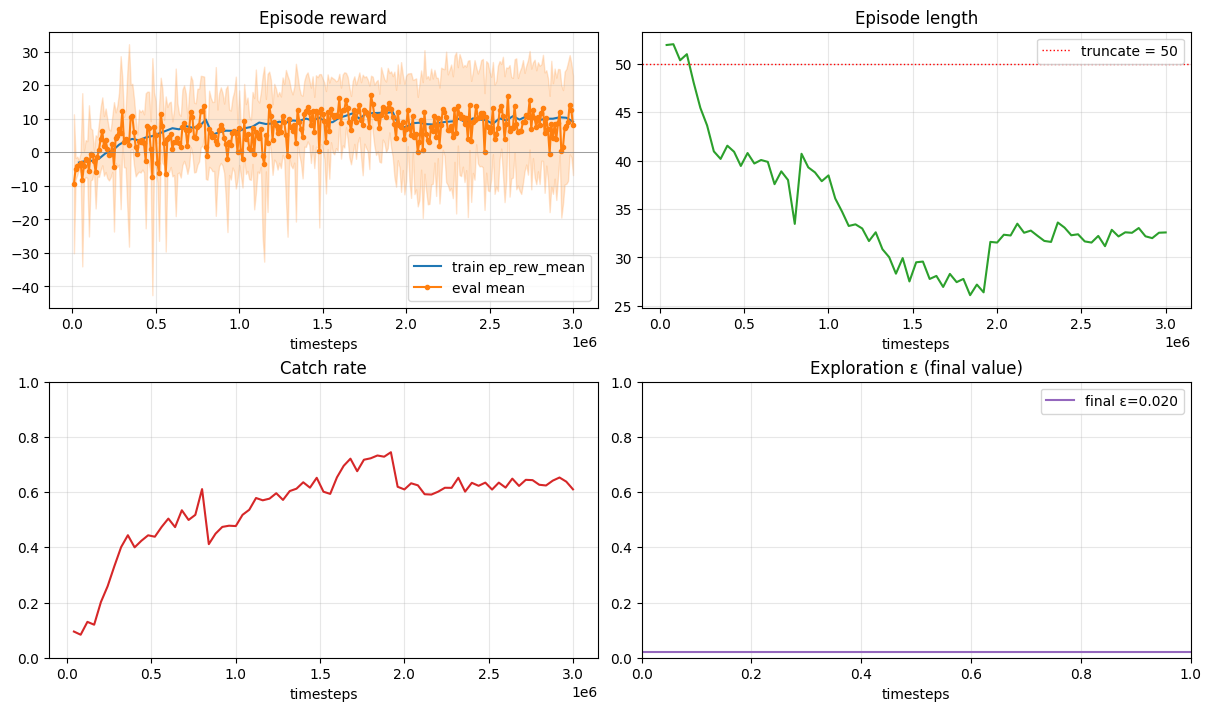

logged 75 metric points


In [44]:
h  = metrics_cb.history
ts = np.asarray(h['timesteps'])

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

# Episode reward
ax = axes[0, 0]
if len(ts):
    ax.plot(ts, h['ep_rew_mean'], label='train ep_rew_mean', color='C0')
ev_path = os.path.join(CONFIG['checkpoint_dir'], 'evaluations.npz')
if os.path.exists(ev_path):
    ev = np.load(ev_path)
    ev_mean = ev['results'].mean(axis=1)
    ev_std  = ev['results'].std(axis=1)
    ax.plot(ev['timesteps'], ev_mean, label='eval mean', color='C1', marker='o', markersize=3)
    ax.fill_between(ev['timesteps'], ev_mean - ev_std, ev_mean + ev_std, alpha=0.2, color='C1')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_title('Episode reward'); ax.set_xlabel('timesteps'); ax.legend(); ax.grid(alpha=0.3)

# Episode length
ax = axes[0, 1]
if len(ts):
    ax.plot(ts, h['ep_len_mean'], color='C2')
ax.axhline(CONFIG['max_episode_steps'], color='red', linestyle=':', linewidth=1,
           label=f'truncate = {CONFIG["max_episode_steps"]}')
ax.set_title('Episode length'); ax.set_xlabel('timesteps'); ax.legend(); ax.grid(alpha=0.3)

# Catch rate
ax = axes[1, 0]
if len(ts):
    ax.plot(ts, h['catch_rate'], color='C3')
ax.set_ylim(0, 1); ax.set_title('Catch rate'); ax.set_xlabel('timesteps'); ax.grid(alpha=0.3)

# Exploration epsilon (from model internals)
ax = axes[1, 1]
if hasattr(model, 'exploration_rate'):
    ax.axhline(model.exploration_rate, color='C4', label=f'final ε={model.exploration_rate:.3f}')
ax.set_title('Exploration ε (final value)'); ax.set_xlabel('timesteps')
ax.legend(); ax.grid(alpha=0.3)

plt.show()
print(f'logged {len(ts)} metric points')

## Run history

Comparison of every QRDQN_N run. Each run's CSV summary is in
`rl/runs_summary/QRDQN_N.csv`.

Per-run write-ups below capture *what changed and why* — the actual
metrics come from the CSVs and the `wiki/logs.md` log.


### Comparison plot

All runs side-by-side on the metrics that matter for the project goal.
Loaded from `rl/runs_summary/*.csv`.


In [45]:
import os
import glob
import csv
import matplotlib.pyplot as plt

In [46]:
def _load_run_csv(path: str) -> dict[str, list]:
    cols: dict[str, list] = {}
    with open(path) as fh:
        reader = csv.DictReader(fh)
        for col in reader.fieldnames or []:
            cols[col] = []
        for row in reader:
            for col, raw in row.items():
                cols[col].append(float(raw) if raw != '' else None)
    return cols


def _filter_pairs(steps, values):
    s, v = [], []
    for st, val in zip(steps, values):
        if val is not None:
            s.append(st)
            v.append(val)
    return s, v

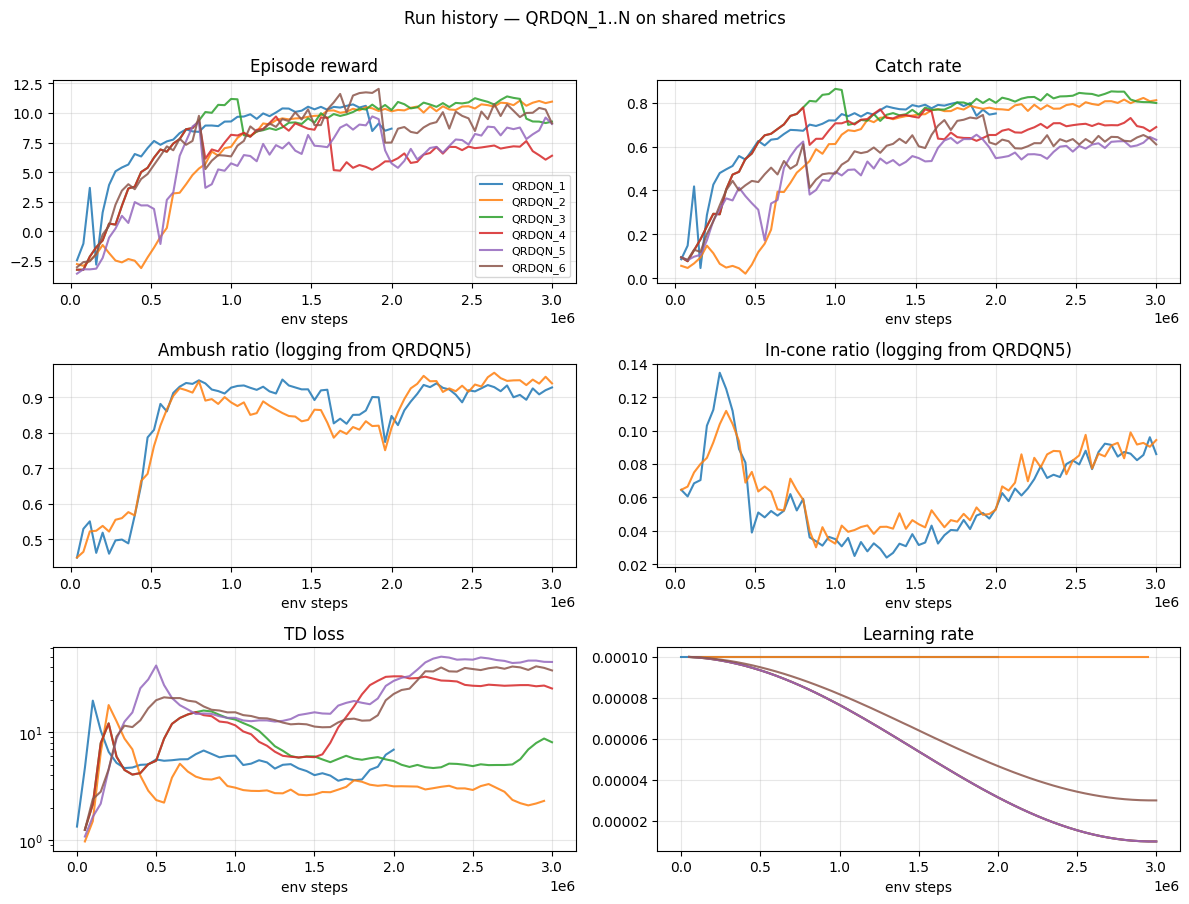

In [81]:
SUMMARY_DIR = 'runs_summary'
runs = sorted(glob.glob(os.path.join(SUMMARY_DIR, 'QRDQN_*.csv')))
data = {os.path.splitext(os.path.basename(p))[0]: _load_run_csv(p) for p in runs}

if not data:
    print(f'No CSVs in {SUMMARY_DIR}/. Run: python rl/tools/dump_run_summary.py --all')
else:
    metrics = [
        ('ep_rew_mean',    'Episode reward'),
        ('catch_rate',     'Catch rate'),
        ('ambush_ratio',   'Ambush ratio (logging from QRDQN5)'),
        ('in_cone_ratio',  'In-cone ratio (logging from QRDQN5)'),
        ('loss',           'TD loss'),
        ('lr',             'Learning rate'),
    ]
    fig, axes = plt.subplots(3, 2, figsize=(12, 9))
    axes = axes.flatten()
    for ax, (col, title) in zip(axes, metrics):
        for run_name, cols in data.items():
            steps, values = _filter_pairs(cols['step'], cols.get(col, []))
            if values:
                ax.plot(steps, values, label=run_name, alpha=0.85)
        ax.set_title(title)
        ax.set_xlabel('env steps')
        ax.grid(alpha=0.3)
        if col == 'loss':
            ax.set_yscale('log')
    axes[0].legend(loc='lower right', fontsize=8)
    fig.suptitle('Run history — QRDQN_1..N on shared metrics', y=1.00)
    fig.tight_layout()
    plt.show()

### Per-run notes

#### QRDQN_1 — minimal observation, sanity check (2M steps)

Observation here was minimal: **only 2 spatial channels** — `ChScent` (Dijkstra distance from player) and
`ChWalkable`. Scalars were the basic set (HP, stamina, distances).

Architecture: plain ResCNN without SE. Curriculum was already wired but
poorly spaced (stages fired at 1.76M / 1.92M — almost at the end of
training). Reward had no ambush bonus and no cone-presence penalty.
Peak `catch_rate` 0.801, final 0.751, `ep_rew_mean` 8.68. Loss tail-mean 4.9
(peak 27.8 after downsample) — stable.

#### QRDQN_2 — observation enrichment + SE channel attention (3M steps)

**New channels** (2 -> 11): `ChClosedDoor`, `ChOtherMonster`, `ChSelfTrail`
(pursuer position trail), `ChPlayerVisNow` (LoS visibility),
`ChPlayerMemory` (last known position), `ChPlayerCone` (flashlight cone),
`ChAgeLastSeen` (Gaussian decay around last-seen), `ChCovertPath`
(covert-Dijkstra with penalty 10 inside cone), `ChPlayerTrail` (player
trail with exponential decay).

**New scalars** (12 -> 16): intercept/exit-related — `intercept_advantage`
("can I cut off the player before exit" — signed difference
`player_to_exit - pursuer_to_intercept`), `player_to_exit_dist`,
`pursuer_to_player_dist`, `player_in_corridor_flag`. Plus per-actor state
including `in_cone_flag` ("am I currently lit up").

**Architecture**: Squeeze-and-Excitation block added after the second
ResBlock (channel attention, reduction=8). Rationale: the 11 channels
carry different tactical signals (covert vs scent vs cone), SE learns to
re-weight them per state instead of blending uniformly.

**The `curriculum_stage` tag is missing from this run's TB events — this was a bug, not an intentional disable.** The training
itself ran with curriculum, but the tag-emission code path was broken in
this version of the callback. Cleanest loss curve of any run (peak 17.9,
tail 2.2). Best raw `catch_rate` among runs — 0.812 final, 0.822 peak. 
`ep_rew_mean` 10.96. LR constant 1e-4.

#### QRDQN_3 — spatial promotion, cosine LR, dilated conv (3M steps)

**Scalars promoted to channels**: "one-point" summaries became proper
spatial channels wherever this exposes route geometry:

- `intercept_advantage` (scalar) -> `ChInterceptPath` (channel 11): no
  longer just "good/bad to intercept", but a **map** of Dijkstra distance
  from the optimal intercept cell. The network sees *where* to intercept
  from, not just "this is a good idea".
- "has the player been here" (previously implicit in player-trail decay)
  -> `ChVisitedCorridorPath` (channel 12): Dijkstra biased toward
  player-visited corridors. Encourages re-using "warm trails" after
  losing LoS.
- Also added `ChFuturePlayerPos` (channel 13): greedy prediction of the
  player's path to exit with 0.8/step decay.

**Which scalars stayed as scalars** (rule: spatial -> channel,
point-summary -> scalar):
- HP, Stamina — per-actor state, no spatial extent.
- TurnsSinceLOS — temporal counter.
- `dist/dx/dy_last_seen`, `nearest_pursuer_dx/dy`, `player_dx/dy` —
  geometric reductions to a single point, no benefit from 11x11
  rasterisation.
- `in_cone_flag`, `cone_dot_product`, `player_in_corridor_flag` —
  boolean / normalised point values.
- `polar_dist_player`, `polar_angle_player` — polar coordinates of the
  pursuer relative to the player, also point values.
- `player_to_exit_dist`, `pursuer_to_player_dist`, `intercept_advantage`
  — kept **alongside** the new channels as fast scalar summaries
  (channel + summary, not channel-or-summary).

Total: **14 channels, 20 scalars, 1714 floats** — the current observation
size.

**Other changes**: dilated convolution (dilation=2 in the second
ResBlock — 5x5 effective receptive field without extra parameters).
Cosine LR `1e-4 -> 1e-5` (first run with the schedule). 5-stage
topology-aware curriculum (small -> medium -> full).

4 stages reached, still bunched in the last ~1.8M steps.
Peak `catch_rate` 0.863, final 0.799 (regressed instage 4 once the distractor was added). 
`ep_rew_mean` final 9.27, max 11.4. Loss peak 15.9 — still stable. First run with the ambush bonus
(+1.5 in this version, before B7 raised it to +3.0). The logs note
`ambush_ratio` ~+10pp over baseline — the first stealth signal, spotted
case-by-case during manual episode review.

#### QRDQN_4 — bug-fix sweep 

3M steps after the bug-fix session: B3 buffer-flush at curriculum
transitions, B5 curriculum spread (stages now fire at 0.8M / 1.28M /
1.6M / 2.4M), B7 ambush bonus raised +1.5 -> +3.0, B12 cone parity fixed.
First run where stage-3 loss diverged: peak 39.76 @ 2.25M with no
recovery. Eval result on `eval_pool/v1`: catch 0.755, ambush 0.607
(== baseline — bug fixes alone did not move stealth), in_cone 0.156.
This established the diagnosis that the *reward function*, not the
architecture or curriculum, was the stealth bottleneck.

#### QRDQN_5 — reward shift 

3M steps with the stealth-shifted reward described in the *Reward design*
section above (catch terminal split + per-step cone-presence cost).
Ambush jumped 0.607 -> **0.929**, in_cone fell 0.156 -> **0.127**, both
clearing the Plan A targets with large margin. Catch fell 0.755 -> 0.685
(intentional tradeoff: 7pp catch for 32pp ambush). Stage-3 loss
divergence got worse (peak 56.86 @ 2.58M, vs 39.76 in QRDQN_4) but
`eval_reward` kept rising to step 2.99M — Q-regression noise, not a
broken policy.


## Q-value heatmap

Visual sanity check: pin the player at a fixed position and angle, then
sweep the pursuer across every walkable cell of the topology and render
`max_a Q(s, a)` as a heatmap. A well-trained policy should show:

- **Bright cells in covered corridors and behind cover** — high value,
  the agent expects to ambush from there.
- **Dark cells inside the player's cone** — low value, exposed positions
  are bad.
- **Smooth gradient toward the player** — the value function captures
  proximity, not random patches.

This is qualitative; it doesn't replace the eval-pool benchmark below.


In [48]:
def render_q_heatmap(model, topology, player_pos, player_angle=0.0, figsize=(5, 3), dpi=80):
    # Returns (H, W, 3) uint8 with Q-value colormap and best-action arrows.
    device = next(model.policy.parameters()).device
    walkable = topology.walkable_points()
    memory = PursuerMemory()
    scent = chase_scent_map(topology, player_pos)

    obs_list = []
    for px, py in walkable:
        obs_list.append(build_observation(
            topology=topology,
            pursuer_pos=(px, py),
            pursuer_hp_frac=1.0,
            pursuer_stamina_frac=1.0,
            memory=memory,
            player_pos=player_pos,
            player_angle_rad=player_angle,
            cone_mask=None,
            scent_map=scent,
        ))

    obs_t = torch.tensor(np.stack(obs_list), dtype=torch.float32, device=device)
    with torch.no_grad():
        quantiles = model.policy.quantile_net(obs_t)
        q_values = quantiles.mean(dim=-1).cpu().numpy()

    best_a = q_values.argmax(axis=1)
    max_q = q_values.max(axis=1)

    q_grid = np.full((topology.height, topology.width), float('nan'))
    for i, (px, py) in enumerate(walkable):
        q_grid[py, px] = max_q[i]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    vmin = np.nanmin(q_grid) if not np.all(np.isnan(q_grid)) else 0
    vmax = np.nanmax(q_grid) if not np.all(np.isnan(q_grid)) else 1
    im = ax.imshow(q_grid, cmap='viridis', vmin=vmin, vmax=vmax,
                   origin='upper', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='max Q')

    arrow_kw = dict(head_width=0.3, head_length=0.2, fc='white', ec='white', alpha=0.7)
    for i, (px, py) in enumerate(walkable):
        dx, dy = ACTION_VECTORS.get(best_a[i], (0, 0))
        if dx != 0 or dy != 0:
            ax.arrow(px, py, dx * 0.4, dy * 0.4, **arrow_kw)

    ax.plot(player_pos[0], player_pos[1], 'ws', markersize=6, label='player')
    ex, ey = topology.exit_point
    ax.plot(ex, ey, 'r*', markersize=8, label='exit')
    ax.set_title(f'player=({player_pos[0]},{player_pos[1]})', fontsize=8)
    ax.legend(loc='upper right', fontsize=6)
    ax.axis('off')
    plt.tight_layout()

    fig.canvas.draw()
    # buffer_rgba() returns memoryview of shape (H, W, 4). Slice alpha off.
    img = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
    plt.close(fig)
    return img

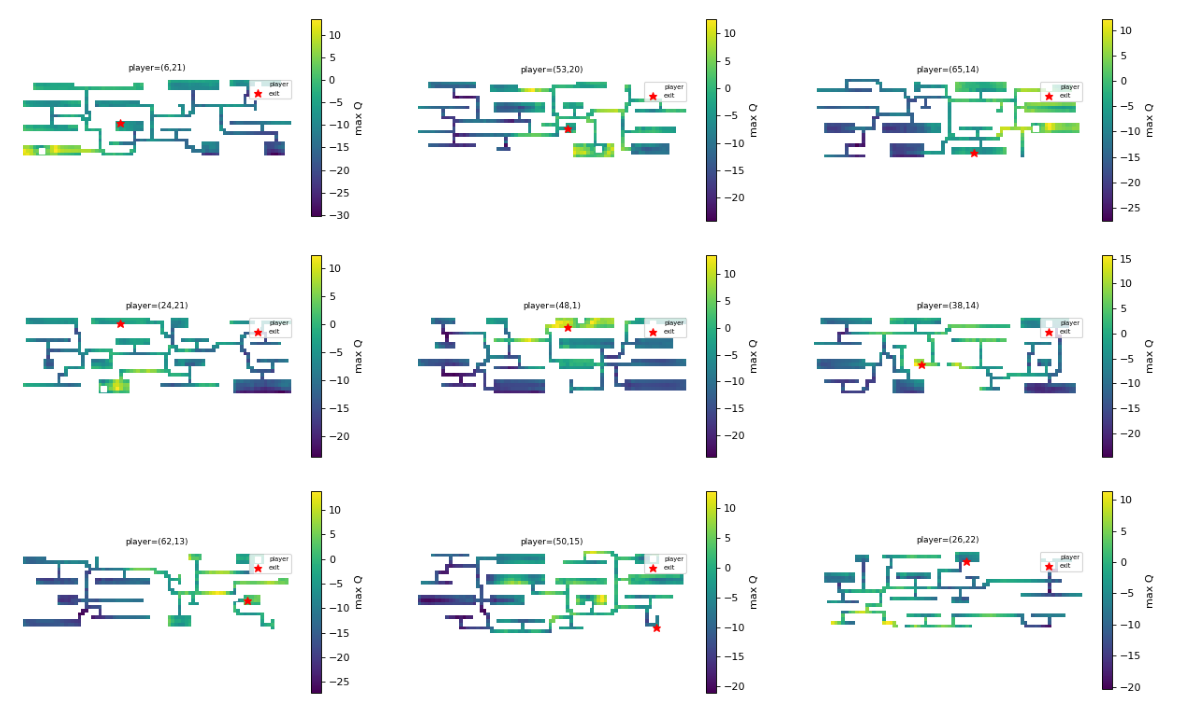

In [49]:
_panel_rows, _panel_cols = 3, 3
_fig, _axes = plt.subplots(_panel_rows, _panel_cols, figsize=(15, 9), dpi=80)
for _i in range(_panel_rows * _panel_cols):
    _env_inner = eval_vec.envs[0]
    _env_inner.reset(seed=100 + _i)
    _img = render_q_heatmap(
        model, _env_inner.topology, _env_inner.player_pos,
        player_angle=_env_inner.player_angle,
    )
    _r, _c = _i // _panel_cols, _i % _panel_cols
    _axes[_r][_c].imshow(_img)
    _axes[_r][_c].axis('off')
plt.tight_layout()
plt.show()

## Evaluation vs baseline

The benchmark is `eval_pool/v1` — a frozen pool of topology + spawn pairs
shipped under `rl/fixtures/eval_pool/`, identified by sha256 prefix. The
pool is the *only* reproducible measurement. Numbers from any
other distribution (training-time rollouts, ad-hoc topologies) are
informative but not comparable across runs.

Each policy is evaluated on N=200 episodes, max_steps=50, default
profile. I compare:

- **`QR-DQN`** — the trained policy (PyTorch in this notebook;
  byte-identical to the exported ONNX).
- **`Baseline (Dijkstra)`** — `BaselinePolicy` greedy chase down the
  exit-scent gradient. Has perfect information (reads `player_pos`
  directly) — represents an unrealistically good chase strategy. Beating
  it on chase metrics is hard and not the point; beating it on stealth
  metrics is the actual goal.

Reported metrics:

| metric | meaning |
|---|---|
| `return` | mean cumulative reward per episode |
| `catch` | episodes ending with `player_hp == 0` |
| `in_cone` | mean fraction of pursuer steps spent inside the player's flashlight cone |
| `ambush_ratio` | of catch episodes, fraction where pursuer was NOT visible the step before the kill |
| `stealth` (composite) | `ambush_ratio - in_cone` — the project's headline metric |


In [50]:
from tabulate import tabulate
import hashlib, os

In [51]:
class BaselinePolicy:
    # Greedy Dijkstra chase. Has perfect information (reads player_pos directly).
    # Acts as skill floor; RL policy must outperform it on ambush/stealth metrics.
    def __init__(self, env):
        self._env = env

    def predict(self, obs, deterministic=True):
        env = self._env
        scent = chase_scent_map(env.topology, env.player_pos)
        ox, oy = env.pursuer_pos
        center_val = int(scent[oy, ox])
        candidates, min_val = [], center_val
        for action, (dx, dy) in ACTION_VECTORS.items():
            if action == ACTION_WAIT:
                continue
            nx, ny = ox + dx, oy + dy
            if not env.topology.is_walkable(nx, ny):
                continue
            v = int(scent[ny, nx])
            if v < min_val:
                min_val, candidates = v, [(action, nx, ny)]
            elif v == min_val:
                candidates.append((action, nx, ny))
        if not candidates:
            return ACTION_WAIT, None
        px, py = env.player_pos
        action, _, _ = min(candidates, key=lambda c: (abs(c[1]-px)+abs(c[2]-py), c[0]))
        return action, None


def rollout(policy_name, policy, eval_env, n_episodes=30, seed_base=1000):
    returns, lengths, in_cone_ratios = [], [], []
    catches, total_hits, ambush_hits = 0, 0, 0
    first_hit_turns = []
    for ep in range(n_episodes):
        obs, _ = eval_env.reset(seed=seed_base + ep)
        ep_ret, ep_steps, ep_in_cone = 0.0, 0, 0
        ep_hits, ep_ambush, first_hit = 0, 0, None
        done, info = False, {}
        while not done:
            action, _ = policy.predict(obs, deterministic=True)
            obs, r, term, trunc, info = eval_env.step(int(action))
            ep_ret += r
            ep_steps += 1
            if info.get('in_cone'):
                ep_in_cone += 1
            if info.get('pursuer_hit'):
                ep_hits += 1
                if first_hit is None:
                    first_hit = ep_steps
            if info.get('ambush_hit'):
                ep_ambush += 1
            done = term or trunc
        returns.append(ep_ret)
        lengths.append(ep_steps)
        in_cone_ratios.append(ep_in_cone / max(ep_steps, 1))
        total_hits += ep_hits
        ambush_hits += ep_ambush
        if info.get('caught'):
            catches += 1
        if first_hit is not None:
            first_hit_turns.append(first_hit)
    avg_in_cone = float(np.mean(in_cone_ratios))
    ambush_ratio = ambush_hits / max(total_hits, 1)
    return {
        'policy': policy_name,
        'avg_return': float(np.mean(returns)),
        'std_return': float(np.std(returns)),
        'catch_rate': catches / n_episodes,
        'avg_in_cone': avg_in_cone,
        'avg_length': float(np.mean(lengths)),
        'avg_first_hit': float(np.mean(first_hit_turns)) if first_hit_turns else float('nan'),
        'total_hits': total_hits,
        'ambush_ratio': ambush_ratio,
        # Composite stealth score: higher = more ambush kills relative to
        # total hits AND less time spent visible to the player. Primary
        # success signal vs Dijkstra (see wiki/plan.md Plan A).
        'stealth': ambush_ratio - avg_in_cone,
    }

In [69]:
EVAL_POOL_DIR        = 'fixtures/eval_pool'
EVAL_POOL_VERSION    = 'v1'         # bump when pool is regenerated
EVAL_MAX_STEPS       = 50           # frozen, NOT CONFIG['max_episode_steps']
EVAL_FIXED_PROFILE   = 'default'    # frozen
EVAL_SPAWN_RADIUS    = (3, 8)       # frozen
EVAL_N_EPISODES      = 200          # 30 binary outcomes have ~12pp Wilson noise
EVAL_N_EPISODES_EXT  = 800
EVAL_SEED_BASE       = 1_000_000

In [66]:
def _eval_pool_hash() -> str:
    h = hashlib.sha256()
    for name in sorted(os.listdir(EVAL_POOL_DIR)):
        if name.endswith('.json'):
            with open(os.path.join(EVAL_POOL_DIR, name), 'rb') as f:
                h.update(f.read())
    return h.hexdigest()[:12]

eval_env = PursuerEnv(
    EVAL_POOL_DIR, scripted_player_policy,
    max_episode_steps=EVAL_MAX_STEPS,
    fixed_profile=EVAL_FIXED_PROFILE,
    spawn_radius=EVAL_SPAWN_RADIUS,
    distractor_prob=0.0,
    randomize_player_profile=False,
    seed=EVAL_SEED_BASE,
)

In [67]:
results = [
    rollout('QR-DQN', model, eval_env, n_episodes=EVAL_N_EPISODES, seed_base=EVAL_SEED_BASE),
    rollout('Baseline (Dijkstra)', BaselinePolicy(eval_env), eval_env,
            n_episodes=EVAL_N_EPISODES, seed_base=EVAL_SEED_BASE),
]

print(f'eval_pool: {EVAL_POOL_DIR} ({EVAL_POOL_VERSION}, sha256[:12]={_eval_pool_hash()})')
print(f'episodes: {EVAL_N_EPISODES}, max_steps: {EVAL_MAX_STEPS}, profile: {EVAL_FIXED_PROFILE}')

def _fmt_first_hit(v: float) -> str:
    return f'{v:.1f}' if v == v else 'nan'

rows = [[
    r['policy'],
    f"{r['avg_return']:.2f} +/- {r['std_return']:.2f}",
    f"{r['catch_rate']:.1%}",
    f"{r['avg_in_cone']:.3f}",
    f"{r['avg_length']:.1f}",
    _fmt_first_hit(r['avg_first_hit']),
    r['total_hits'],
    f"{r['ambush_ratio']:.1%}",
    f"{r['stealth']:+.3f}",
] for r in results]

headers = ['policy', 'return', 'catch', 'in_cone', 'len', '1st_hit', 'hits', 'ambush', 'stealth']
print(tabulate(rows, headers=headers, tablefmt='simple'))

eval_pool: fixtures/eval_pool (v1, sha256[:12]=0d940a0bfd82)
episodes: 800, max_steps: 50, profile: default
policy               return           catch      in_cone    len    1st_hit    hits  ambush      stealth
-------------------  ---------------  -------  ---------  -----  ---------  ------  --------  ---------
QR-DQN               11.56 +/- 15.97  66.6%        0.126   25.5       16.4    1119  94.7%         0.821
Baseline (Dijkstra)  12.66 +/- 12.02  86.4%        0.197   17.7       13.6    1401  57.7%         0.38


## Improved evaluation
Methodologically-corrected evaluation with Wilson 95% CI on catch.

Two fixes vs the eval above:
1) Also load best_model.zip (saved by EvalCallback at peak periodic-eval
      reward) and re-evaluate it under the FROZEN eval_pool/v1 protocol.
      Periodic eval_env follows the curriculum, so its 'best' may have peaked
      on an easier stage than eval_pool/v1 -- only this protocol is honest.
2) Report Wilson 95% CI on catch. At n=800 binary outcomes near p=0.65 the
      Wilson SE is ~3.4pp, so a 0.5pp miss vs the revert threshold is noise,
      not a regression. CI-aware decision rule:
        SHIP       if catch_lower_95  >= 0.65  (definitively above)
        REVERT     if catch_upper_95  <  0.65  (definitively below)
        AMBIGUOUS  if CI straddles 0.65        (run more episodes / human call)

In [ ]:
from sb3_contrib import QRDQN
from statistics import NormalDist

In [71]:
best_path = f"{CONFIG['checkpoint_dir']}/best_model.zip"
best_model_loaded = QRDQN.load(best_path)

In [73]:
def _wilson_ci(successes: int, n: int, confidence: float = 0.95) -> tuple[float, float]:
    """Wilson score interval for a binomial proportion."""
    if n == 0:
        return (0.0, 1.0)
    p = successes / n
    z = NormalDist().inv_cdf(0.5 + confidence / 2)
    denom = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half = (z * ((p * (1 - p) / n + z * z / (4 * n * n)) ** 0.5)) / denom
    return (centre - half, centre + half)


In [74]:
results_with_best = [
    rollout('QR-DQN (best_model)', best_model_loaded, eval_env,
            n_episodes=EVAL_N_EPISODES_EXT, seed_base=EVAL_SEED_BASE),
    rollout('QR-DQN (final)',      model,             eval_env,
            n_episodes=EVAL_N_EPISODES_EXT, seed_base=EVAL_SEED_BASE),
    rollout('Baseline (Dijkstra)', BaselinePolicy(eval_env), eval_env,
            n_episodes=EVAL_N_EPISODES_EXT, seed_base=EVAL_SEED_BASE),
]

In [79]:
print(f'eval_pool: {EVAL_POOL_DIR} ({EVAL_POOL_VERSION}, sha256[:12]={_eval_pool_hash()})')
print(f'episodes: {EVAL_N_EPISODES_EXT}, max_steps: {EVAL_MAX_STEPS}, profile: {EVAL_FIXED_PROFILE}')

rows_v2 = []
for r in results_with_best:
    catches_n = round(r['catch_rate'] * EVAL_N_EPISODES_EXT)
    lo, hi = _wilson_ci(catches_n, EVAL_N_EPISODES_EXT)
    rows_v2.append([
        r['policy'],
        f"{r['avg_return']:.2f} +/- {r['std_return']:.2f}",
        f"{r['catch_rate']:.1%}",
        f"[{lo:.3f}, {hi:.3f}]",
        f"{r['avg_in_cone']:.3f}",
        f"{r['ambush_ratio']:.1%}",
        f"{r['stealth']:+.3f}",
    ])

headers_v2 = ['policy', 'return', 'catch', 'catch 95% CI', 'in_cone', 'ambush', 'stealth']
print(tabulate(rows_v2, headers=headers_v2, tablefmt='simple'))

eval_pool: fixtures/eval_pool (v1, sha256[:12]=0d940a0bfd82)
episodes: 800, max_steps: 50, profile: default
policy               return           catch    catch 95% CI      in_cone  ambush      stealth
-------------------  ---------------  -------  --------------  ---------  --------  ---------
QR-DQN (best_model)  10.45 +/- 15.15  68.5%    [0.652, 0.716]      0.097  80.2%         0.706
QR-DQN (final)       11.56 +/- 15.97  66.6%    [0.633, 0.698]      0.126  94.7%         0.821
Baseline (Dijkstra)  12.66 +/- 12.02  86.4%    [0.838, 0.886]      0.197  57.7%         0.38


In [76]:
THRESHOLDS = {'catch': 0.65, 'in_cone': 0.13, 'ambush': 0.85, 'stealth': 0.75}

In [80]:
print()
print('Ship/revert decision (CI-aware on catch, point estimate on others):')
for r in results_with_best:
    if r['policy'].startswith('Baseline'):
        continue
    catches_n = round(r['catch_rate'] * EVAL_N_EPISODES_EXT)
    catch_lo, catch_hi = _wilson_ci(catches_n, EVAL_N_EPISODES_EXT)
    if catch_hi < THRESHOLDS['catch']:
        catch_verdict = 'REVERT'
    elif catch_lo >= THRESHOLDS['catch']:
        catch_verdict = 'SHIP'
    else:
        catch_verdict = 'AMBIGUOUS'
    other_fails = []
    if r['avg_in_cone']  > THRESHOLDS['in_cone']: other_fails.append('in_cone')
    if r['ambush_ratio'] < THRESHOLDS['ambush']:  other_fails.append('ambush')
    if r['stealth']      < THRESHOLDS['stealth']: other_fails.append('stealth')
    if other_fails or catch_verdict == 'REVERT':
        verdict = 'REVERT'
    elif catch_verdict == 'SHIP':
        verdict = 'SHIP'
    else:
        verdict = 'AMBIGUOUS (catch CI spans 0.65)'
    print(f"  {r['policy']:<25}  {verdict}  catch={catch_verdict}  other_fails={other_fails or 'none'}")


Ship/revert decision (CI-aware on catch, point estimate on others):
  QR-DQN (best_model)        REVERT  catch=SHIP  other_fails=['ambush', 'stealth']
  QR-DQN (final)             AMBIGUOUS (catch CI spans 0.65)  catch=AMBIGUOUS  other_fails=none


In [55]:
# RNG determinism sanity: identical seed_base must give byte-identical baseline.
# Guards against future global-rng / set-iteration regressions.
_env_a = PursuerEnv(CONFIG['topologies_full'], scripted_player_policy,
                    max_episode_steps=CONFIG['max_episode_steps'], seed=999)
_env_b = PursuerEnv(CONFIG['topologies_full'], scripted_player_policy,
                    max_episode_steps=CONFIG['max_episode_steps'], seed=999)
_r_a = rollout('Det-run-a', BaselinePolicy(_env_a), _env_a, n_episodes=5, seed_base=1000)
_r_b = rollout('Det-run-b', BaselinePolicy(_env_b), _env_b, n_episodes=5, seed_base=1000)
# Compare everything except the policy name label.
_r_a_cmp = {k: v for k, v in _r_a.items() if k != 'policy'}
_r_b_cmp = {k: v for k, v in _r_b.items() if k != 'policy'}
assert _r_a_cmp == _r_b_cmp, f'baseline non-deterministic: {_r_a_cmp} vs {_r_b_cmp}'
print('baseline determinism OK')

baseline determinism OK


## ONNX export + parity check

The trained PyTorch model is wrapped in a thin `_QRDQNActor` that reduces
the (batch, n_actions, n_quantiles) output to (batch, n_actions) logits
(the Go runtime does `argmax` over the per-action mean, identical to
PyTorch). Exported with `opset_version=18`, input name `"input"`, output
name `"logits"` — these names are load-bearing for the Go side
(`internal/domain/service/rl_onnx.go`).

Parity check below verifies that the ONNX graph and the PyTorch model
produce the **same `argmax` action** on N=1000 random observations.
Sub-ULP numerical drift in opset 18 is acceptable; what matters for
gameplay is that Go's argmax matches Python's argmax.


In [56]:
import onnxruntime as ort

In [57]:
class _QRDQNActor(nn.Module):
    # Averages quantile estimates -> (batch, n_actions) logits for Go argmax.
    def __init__(self, q_net):
        super().__init__()
        self.q_net = q_net

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        return self.q_net(obs).mean(dim=-1)

In [58]:
actor = _QRDQNActor(model.policy.quantile_net).eval()
dummy = torch.zeros(1, OBSERVATION_SIZE, dtype=torch.float32)

with torch.no_grad():
    torch.onnx.export(
        actor, dummy, CONFIG['model_out'],
        input_names=['input'], output_names=['logits'],
        opset_version=18, dynamic_axes=None,
    )
print('exported', CONFIG['model_out'])

# Parity check: argmax(logits) must match between PyTorch and ONNX on
# every sample. Sub-ULP numerical drift in opset 18 does not change which
# action Go picks; max|diff| is logged only as a diagnostic.
sess = ort.InferenceSession(CONFIG['model_out'])
rng = np.random.default_rng(0)
max_diff = 0.0
argmax_matches = 0
N = 1000
for _ in range(N):
    # grid [0,1] for binary/normalised channels; scalars [-1,1] for signed features.
    grid_in = rng.uniform(0.0, 1.0, size=(1, OBSERVATION_GRID_FLOATS)).astype(np.float32)
    scalar_in = rng.uniform(-1.0, 1.0, size=(1, OBSERVATION_SCALARS)).astype(np.float32)
    sample = np.concatenate([grid_in, scalar_in], axis=1)

    with torch.no_grad():
        py_out = actor(torch.from_numpy(sample)).numpy()
    ort_out = sess.run(['logits'], {'input': sample})[0]
    max_diff = max(max_diff, float(np.max(np.abs(py_out - ort_out))))
    # numpy 2.x: int(arr_shape_1) raises TypeError; use .item() to extract scalar.
    if int(py_out.argmax(-1).item()) == int(ort_out.argmax(-1).item()):
        argmax_matches += 1

print(f'max |PyTorch - ONNX| = {max_diff:.2e}')
print(f'argmax agreement = {argmax_matches}/{N}')
assert max_diff < 1e-3, f'ONNX numerical parity drift too large: {max_diff:.2e}'
assert argmax_matches == N, f'ONNX argmax disagreement on {N - argmax_matches} samples'


W0428 12:49:48.527000 96041 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0428 12:49:48.530000 96041 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0428 12:49:48.531000 96041 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool


[torch.onnx] Obtain model graph for `_QRDQNActor([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `_QRDQNActor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/copyreg.py:104: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 6 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅
exported models/pursuer.onnx
max |PyTorch - ONNX| = 1.60e-04
argmax agreement = 1000/1000


## Generalization rollout across all scripted-player profiles.

In [59]:
from pursuer_env import PursuerEnv
from scripted_player import scripted_player_policy
from tabulate import tabulate

In [60]:
PROFILES = ['stone', 'training_dummy', 'default', 'aggressive', 'cautious', 'timid']
N_EP = 30

In [61]:
def run_rollout(policy_fn, profile: str, n_ep: int = N_EP) -> dict:
    env = PursuerEnv(
        CONFIG['topologies_full'], scripted_player_policy,
        max_episode_steps=CONFIG['max_episode_steps'],
        fixed_profile=profile, distractor_prob=0.0,
        randomize_player_profile=False, seed=999,
    )
    caught = 0
    rewards = []
    for ep in range(n_ep):
        obs, _ = env.reset(seed=10_000 + ep)
        ep_r, done, info = 0.0, False, {}
        while not done:
            action, _ = policy_fn(obs, env)
            obs, r, term, trunc, info = env.step(action)
            ep_r += r
            done = term or trunc
        rewards.append(ep_r)
        if info.get('caught'):
            caught += 1
    return {
        'profile': profile,
        'catch_rate': caught / n_ep,
        'ep_rew_mean': float(np.mean(rewards)),
    }


def qrdqn_policy(obs, env):
    a, _ = model.predict(obs, deterministic=True)
    return int(a), None

In [62]:
rows = []
for p in PROFILES:
    r = run_rollout(qrdqn_policy, p)
    rows.append([r['profile'], f"{r['catch_rate']:.1%}", f"{r['ep_rew_mean']:.2f}"])
print(tabulate(rows, headers=['profile', 'catch', 'rew_mean'], tablefmt='simple'))

profile         catch      rew_mean
--------------  -------  ----------
stone           40.0%          6.54
training_dummy  56.7%          9.89
default         63.3%         11.35
aggressive      70.0%         13.42
cautious        76.7%         14.08
timid           70.0%         14.01
